In [1]:
import lhapdf
import pyhepmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pdf_name = "NNPDF23_lo_as_0130_qed"
pdf_set = lhapdf.getPDFSet(pdf_name)
pdf_size = pdf_set.size-1

In [3]:
pdf_set.uncertainty

<bound method PDFSet.uncertainty of PDFSet<NNPDF23_lo_as_0130_qed, 100 replicas vars: 36 keys, 31 local>>

In [4]:
inputFile = "/Users/ramos/mg5amcnlo/nuDIS_charged/Events/run_01/tag_1_pythia8_events.hepmc.gz"

In [5]:
with pyhepmc.open(inputFile, format="hepmc2") as file:
    events = list(file)
n_events = len(events)

In [6]:
n_events

9997

In [7]:
particles_dict = {}

for i, event in enumerate(events):
    # take only final state particles
    for p in event.particles:
        if p.status != 1: 
            continue
        if p.pid not in particles_dict:
            particles_dict[p.pid] = {}
        

In [8]:
pT_dict = {}
y_dict = {}
weight_dict = {}
m_dict = {}
multiplicity = {}
unc_dict = {}

for i, event in enumerate(events):
    for p in event.particles:
        if p.status != 1:  # not final state
            continue
    
        pN = p.momentum
        if p.pid not in pT_dict:
            pT_dict[p.pid] = []

        pT_dict[p.pid].append(pN.pt())

        # collect weight from events
        # weights: 0 = central, 1 = central, scale (9pt), PDF
        w = event.weights[0]/n_events
        if p.pid not in weight_dict:
            weight_dict[p.pid] = []
        weight_dict[p.pid].append(w)

        # this is a bit hard coded to the hepmc file, but it obtained the 9-point scale variation for dynamic_scale_choice = 1 (sum of pt)
        unc = np.array(event.weights[3:19:5]+event.weights[22:43:5])
        if p.pid not in unc_dict:
            unc_dict[p.pid] = []
        unc_dict[p.pid].append(unc/n_events)
        
        y = pN.rap()
        if p.pid not in y_dict:
            y_dict[p.pid] = []
        y_dict[p.pid].append(y)
    
        

    #     if p.pid not in m_dict:
    #         m_dict[p.pid] = 0
    #     m_dict[p.pid] += 1

    # for id in m_dict.keys():
    #     if not id in multiplicity:
    #         multiplicity[id] = []
    #     multiplicity[id].append(m_dict[id])
    #     m_dict[id] = 0



In [9]:
unc_22 = np.array(unc_dict[22])

In [10]:
unc_22_min = []
unc_22_max = []
for unc in unc_22:
    unc_22_min.append(min(unc))
    unc_22_max.append(max(unc))

In [11]:
len(unc_22_min), len(unc_22_max)

(89527, 89527)

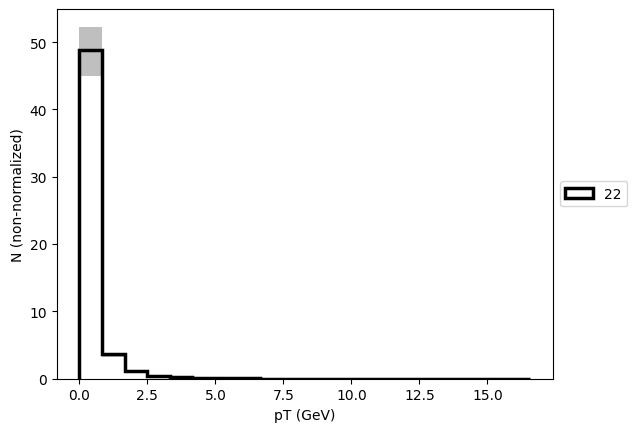

In [23]:
fig = plt.figure()

for pid, pT in pT_dict.items():
    if pid != 22:
        continue
    unc_min = []
    unc_max = []
    for unc in unc_dict[pid]:
        unc_min.append(min(unc))
        unc_max.append(max(unc))

    binc, binEdges, _ = plt.hist(pT, bins=20, histtype='step', label=pid, color='black', linewidth=2.5, weights=weight_dict[pid])
    binCenter = (binEdges[:-1] + binEdges[1:]) / 2
    error_max, _ = np.histogram(pT, bins=binEdges, weights=np.array(unc_max))
    error_min, _ = np.histogram(pT, bins=binEdges, weights=np.array(unc_min))
    # plt.errorbar(binCenter, binc, yerr=[binc-error_min, error_max-error_min], marker='.', drawstyle='steps-mid')
    plt.bar(x=binCenter, height=error_max-error_min, bottom=error_min, width=np.diff(binEdges), alpha=0.5, color='gray')


# plt.yscale('log')
# plt.xlim(-0.05,2.05)
plt.xlabel('pT (GeV)')
plt.ylabel('N (non-normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [21]:
error_max

array([ 5.22933361e+01,  3.78900612e+00,  1.11687076e+00,  4.73801770e-01,
        2.23745685e-01,  1.23066918e-01,  5.42436613e-02,  4.68388030e-02,
        2.90683928e-02,  1.16210227e-02,  8.61010418e-03,  8.02901503e-03,
        6.11603480e-03,  3.66962089e-03,  1.83481044e-03,  0.00000000e+00,
       -3.70768401e-04,  0.00000000e+00,  0.00000000e+00,  6.11603481e-04])

In [22]:
error_min

array([ 4.49357612e+01,  3.28214624e+00,  9.65495410e-01,  4.08088875e-01,
        1.90384788e-01,  1.03644805e-01,  4.56438544e-02,  3.91938374e-02,
        2.42856275e-02,  9.52490991e-03,  6.96803946e-03,  6.84733216e-03,
        4.86713127e-03,  2.86445051e-03,  1.46391461e-03,  0.00000000e+00,
       -6.11603491e-04,  0.00000000e+00,  0.00000000e+00,  4.14208202e-04])

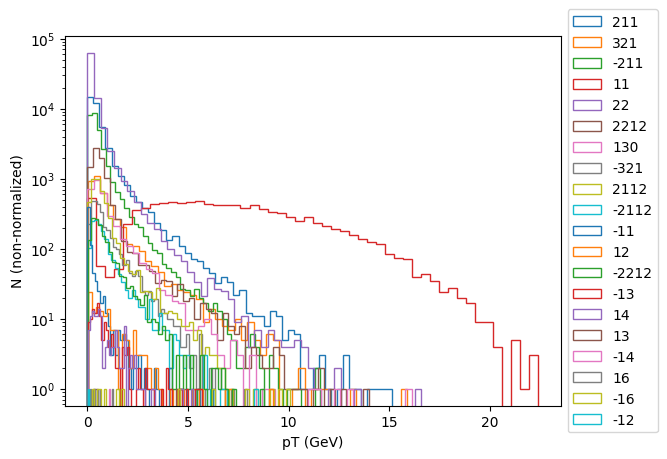

In [10]:
fig = plt.figure()

for pid, pT in pT_dict.items():
    plt.hist(pT, bins=50, histtype='step', label=pid)

plt.yscale('log')
plt.xlabel('pT (GeV)')
plt.ylabel('N (non-normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

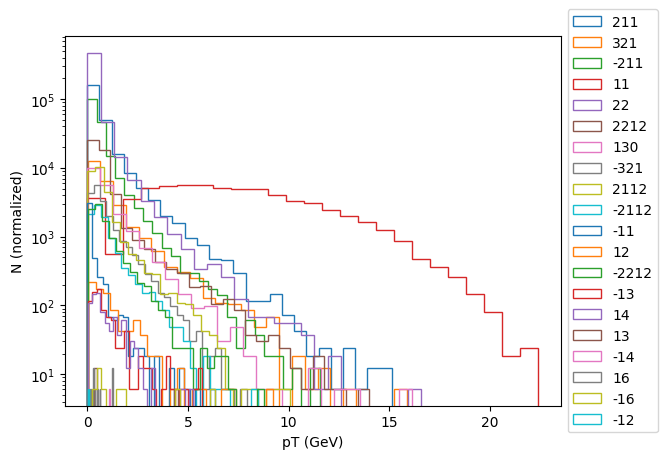

In [12]:
fig = plt.figure()

for pid, pT in pT_dict.items():
    # if pid == -12:
    #     continue
    plt.hist(pT, bins=25, histtype='step', label=pid, weights=weight_dict[pid])

plt.yscale('log')
# plt.ylim(1e-2,1e2)
plt.xlabel('pT (GeV)')
plt.ylabel('N (normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

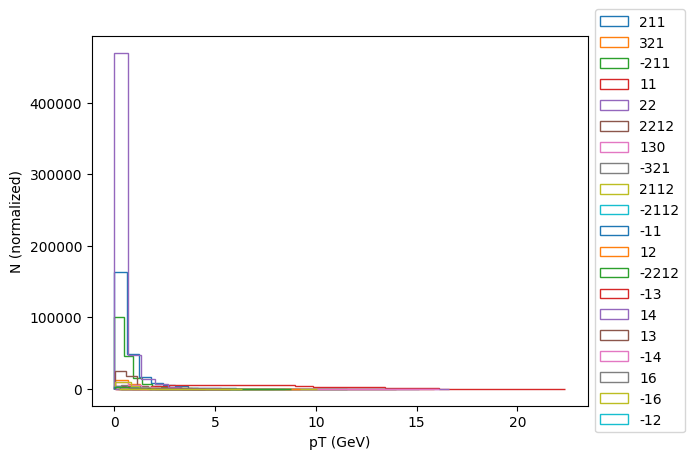

In [13]:
fig = plt.figure()

for pid, pT in pT_dict.items():
    plt.hist(pT, bins=25, histtype='step', label=pid, weights=weight_dict[pid])

# plt.yscale('log')
# plt.ylim(1e-4,1)
plt.xlabel('pT (GeV)')
plt.ylabel('N (normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

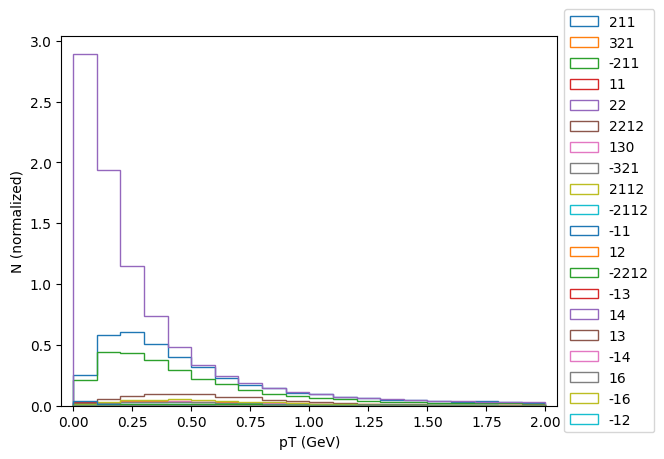

In [14]:
fig = plt.figure()

for pid, pT in pT_dict.items():
    plt.hist(pT, bins=20, histtype='step', label=pid, weights=[1/n_events]*len(pT), range=(0,2))

# plt.yscale('log')
# plt.ylim(1e-4,1)
plt.xlim(-0.05,2.05)
plt.xlabel('pT (GeV)')
plt.ylabel('N (normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

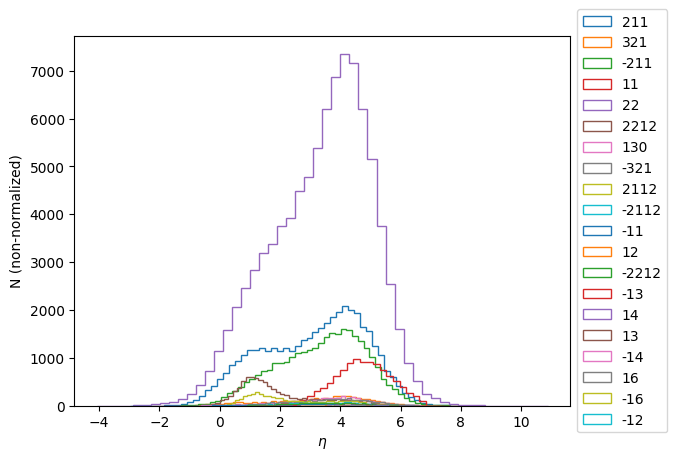

In [15]:
fig = plt.figure()

for pid, y in y_dict.items():
    plt.hist(y, bins=50, histtype='step', label=pid)

# plt.xlim(-0.05,2)
# plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel('N (non-normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

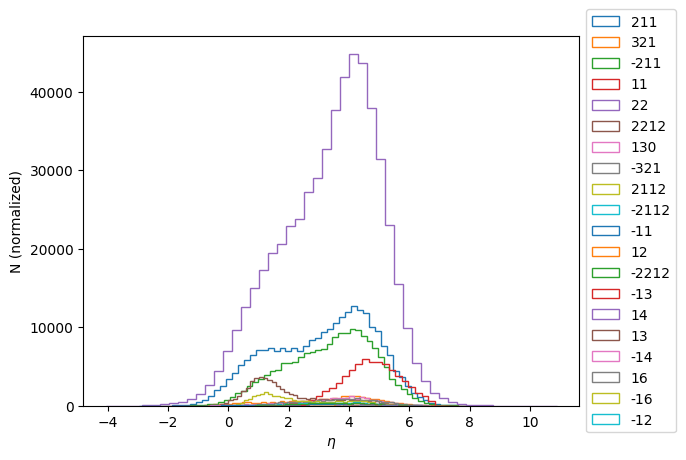

In [16]:
fig = plt.figure()

for pid, y in y_dict.items():
    plt.hist(y, bins=50, histtype='step', label=pid, weights=weight_dict[pid])

# plt.xlim(-0.05,2)
plt.xlabel(r'$\eta$')
plt.ylabel('N (normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [17]:
# multiplicity plot
multi = {k: [] for k in pT_dict.keys()}

for i, event in enumerate(events):
    m_dict = {k: 0 for k in pT_dict.keys()}
    for p in event.particles:
        if p.status != 1:  # not final state
            continue
        m_dict[p.pid] += 1

    for id in m_dict.keys():
        multi[id].append(m_dict[id])

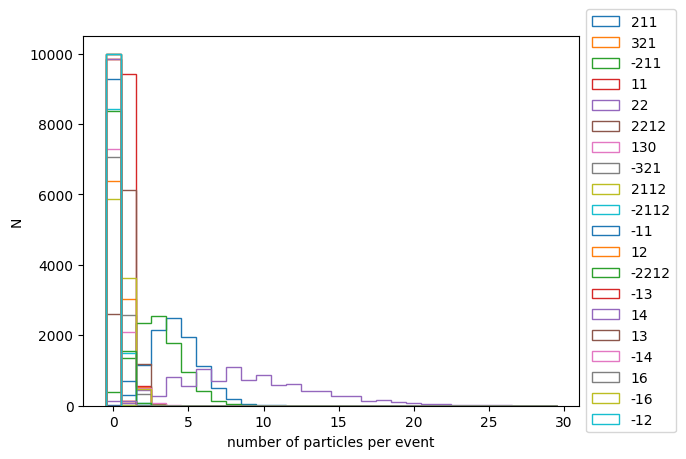

In [18]:
fig = plt.figure()

for pid, m in multi.items():
    # if pid == 130:
    #     continue
    plt.hist(m, bins=30, histtype='step', label=pid, range=(0,30), align='left')

# plt.xlim(-0.05,2)
plt.xlabel('number of particles per event')
plt.ylabel('N')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()